# ftsim on LightStim - pluggable FT logical-circuit simulation

Two orthogonal axes: the **code** (encoded structure, from `lightstim.qec_code`) and the
**protocol** (what to do with it). Magic-state supply for `T` is a separate flag.

`run_pipeline(lc, p, code=..., protocol=..., zero_lvl_distill=/distillation=/cultivation=)`

In [1]:
from ftsim import LogicalCircuit, run_pipeline, check_unitary, list_codes, list_protocols
import numpy as np, matplotlib.pyplot as plt
print("codes    :", list_codes())
print("protocols:", list_protocols())

codes    : ['color', 'h6', 'repetition', 'rotated_surface', 'steane']
protocols: ['processor', 'memory', 'factory']


## 1. Processor - Clifford circuit (exact, fault-tolerant)

In [2]:
lc = LogicalCircuit([("H", 0), ("CNOT", 0, 1), ("S", 1)])
print("unitary check:", check_unitary(lc))
print(run_pipeline(lc, p=1e-3, shots=50_000))

unitary check: (True, {'tvd[0]': 0.001600000000000018, 'tvd[1]': 0.001600000000000018, 'tvd[+]': 0.0006000000000000172})
FTReport(code=h6, protocol=processor, n=2, T=0, phys=20, shots=50000, accept=0.6426, LER=6.224e-05 (floor 0), unitary_ok=True, 0.1s)


## 2. Processor - non-Clifford circuit; pick the magic-state factory for T

In [3]:
lc_t = LogicalCircuit([("T", 0), ("CNOT", 0, 1), ("T", 1)])
for flag in ({}, {"zero_lvl_distill": True}, {"distillation": 1}):
    r = run_pipeline(lc_t, p=1e-3, shots=80_000, **flag)
    print(f"  {str(flag) or '(default)':28s} magic={r.magic:26s} accept={r.post_selection_rate:.4f}  LER={r.logical_error_rate:.3g}")
# not-yet-implemented factory protocols fail loudly
for flag in ({"cultivation": True}, {"distillation": 2}):
    try:
        run_pipeline(lc_t, p=1e-3, **flag)
    except NotImplementedError as e:
        print(f"  {str(flag):28s} -> NotImplementedError: {str(e)[:70]}...")

  {}                           magic=h6_zero_level_distillation accept=0.0103  LER=0


  {'zero_lvl_distill': True}   magic=h6_zero_level_distillation accept=0.0103  LER=0


  {'distillation': 1}          magic=h6_distillation            accept=0.0103  LER=0
  {'cultivation': True}        -> NotImplementedError: magic state cultivation (arXiv:2409.17595) is not implemented; use zer...
  {'distillation': 2}          -> NotImplementedError: level-2 concatenated [[36,4,4]] distillation is not implemented (Light...


## 3. protocol='factory' - benchmark a magic-state factory in isolation

In [4]:
for flag in ({"zero_lvl_distill": True}, {"distillation": 1}):
    accs, lers, ps = [], [], np.array([0.0, 1e-3, 3e-3, 8e-3])
    for p in ps:
        r = run_pipeline(None, p=p, protocol="factory", shots=40_000, **flag)
        accs.append(r.post_selection_rate); lers.append(r.logical_error_rate)
    print(f"  {str(flag):26s} yield {np.round(accs,3)}  out-infidelity {np.array(lers)}")

  {'zero_lvl_distill': True} yield [1.    0.951 0.861 0.671]  out-infidelity [0.        0.        0.0001743 0.0010438]
  {'distillation': 1}        yield [1.    0.941 0.835 0.62 ]  out-infidelity [0.         0.00124914 0.00329292 0.00971422]


## 4. Swap the code

In [5]:
lc_xc = LogicalCircuit([("X", 0), ("CNOT", 0, 1)])
for c in ("h6", "rotated_surface"):
    r = run_pipeline(lc_xc, p=2e-3, code=c, shots=30_000)
    print(f"  {c:16s} accept={r.post_selection_rate:.3f}  phys={r.physical_qubits}  unitary_ok={r.unitary_check_passed}")
r = run_pipeline(lc_xc, p=2e-3, code="rotated_surface", code_kwargs={"distance": 5}, shots=30_000)
print(f"  rotated_surface d=5   accept={r.post_selection_rate:.3f}  phys={r.physical_qubits}")

  h6               accept=0.525  phys=20  unitary_ok=True


  rotated_surface  accept=0.363  phys=34  unitary_ok=True


  rotated_surface d=5   accept=0.041  phys=98


## 4b. Cross-code magic injection - processor in one code, factory in another

`code="steane"` (= `ColorCode(distance=3)`, `[[7,1,3]]`) processor, magic states
distilled in `factory_code="h6"` and injected. No inter-code coupler -- the
verified `[[6,2,2]]` resource is grown into the Steane code, then teleported.

In [6]:
lc_t = LogicalCircuit([("T", 0)])
for fc in (None, "h6"):
    kw = dict(code="steane", distillation=1, check=False, shots=30_000)
    if fc: kw["factory_code"] = fc
    try:
        r = run_pipeline(lc_t, p=0.0, **kw)
        print(f"  factory_code={str(fc):5s} magic={r.magic:28s} accept={r.post_selection_rate:.3f}  phys={r.physical_qubits}")
    except Exception as e:
        print(f"  factory_code={str(fc):5s} -> {type(e).__name__}: {e}")
# yield across noise
for p in (0.0, 1e-3, 4e-3):
    r = run_pipeline(LogicalCircuit([("T",0),("CNOT",0,1)]), p=p, code="steane",
                     factory_code="h6", distillation=1, shots=30_000, check=False)
    print(f"  p={p:.0e}  accept={r.post_selection_rate:.4f}  LER={r.logical_error_rate:.3g}")

  factory_code=None  -> UnsupportedGate: h6_zero_level_distillation requires an H6 factory (got 'steane')
  factory_code=h6    magic=h6_distillation+inject       accept=0.248  phys=59


  p=0e+00  accept=0.2500  LER=0
  p=1e-03  accept=0.0351  LER=0.00095


  p=4e-03  accept=0.0000  LER=nan


## 5. Swap the protocol - d-round memory for any CSS code

In [7]:
for c in ("h6", "rotated_surface", "repetition", "color"):
    r = run_pipeline(LogicalCircuit([("X", 0)]), p=3e-3, code=c, protocol="memory", rounds=3, shots=20_000)
    print(f"  {c:16s} accept={r.post_selection_rate:.3f}  LER={r.logical_error_rate:.3g}  n_logical={r.n_logical}")

  h6               accept=0.766  LER=6.52e-05  n_logical=2
  rotated_surface  accept=0.642  LER=0  n_logical=1
  repetition       accept=0.919  LER=0  n_logical=1
  color            accept=0.706  LER=7.08e-05  n_logical=1


## 6. Noisy sweep

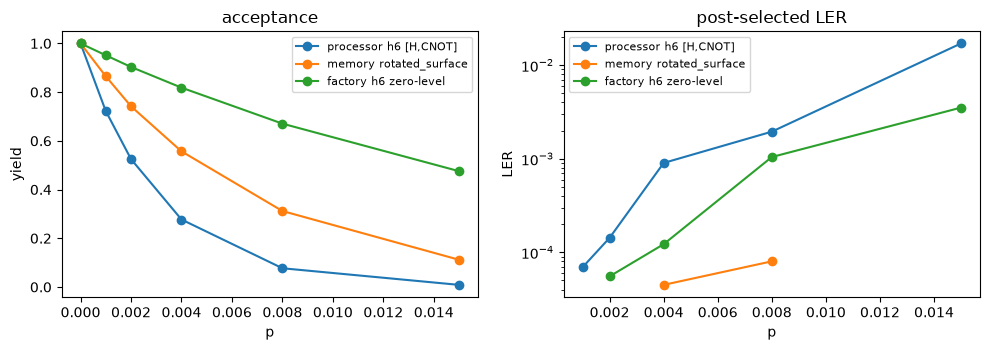

In [8]:
ps = np.array([0.0, 1e-3, 2e-3, 4e-3, 8e-3, 1.5e-2])
rows = {
    "processor h6 [H,CNOT]": dict(lc=LogicalCircuit([("H",0),("CNOT",0,1)]), code="h6"),
    "memory rotated_surface": dict(lc=LogicalCircuit([("X",0)]), code="rotated_surface", protocol="memory", rounds=3),
    "factory h6 zero-level":  dict(lc=None, code="h6", protocol="factory", zero_lvl_distill=True),
}
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
for label, kw in rows.items():
    acc, ler = [], []
    for p in ps:
        r = run_pipeline(p=p, shots=40_000, check=False, **kw)
        acc.append(r.post_selection_rate); ler.append(r.logical_error_rate)
    acc, ler = np.array(acc), np.array(ler)
    ax[0].plot(ps, acc, "o-", label=label)
    ax[1].semilogy(ps[ler > 0], ler[ler > 0], "o-", label=label)
ax[0].set(xlabel="p", ylabel="yield", title="acceptance")
ax[1].set(xlabel="p", ylabel="LER", title="post-selected LER")
ax[0].legend(fontsize=8); ax[1].legend(fontsize=8); plt.tight_layout(); plt.show()

## Extending

* **new code**: `ftsim.backends.register(CodeSpec(name=..., patch_factory=<LightStim class>,
  extraction_block=..., op_set=..., gate_methods={...}))`.
* **new factory protocol**: subclass `ftsim.factory.MagicProtocol`
  (`gadget` for the T source, `build_standalone` for the benchmark) and wire it
  into `make_magic_source`. `Cultivation` and `H6Distillation(level>=2)` are the
  open slots.
* **real T**: a `clifft` execution backend + a true `|T>` magic prep
  (LightStim `feat/magic-h6-protocol`).